Starting data generation...
  Running simulation 10/500...
  Running simulation 20/500...
  Running simulation 30/500...
  Running simulation 40/500...
  Running simulation 50/500...
  Running simulation 60/500...
  Running simulation 70/500...
  Running simulation 80/500...
  Running simulation 90/500...
  Running simulation 100/500...
  Running simulation 110/500...
  Running simulation 120/500...
  Running simulation 130/500...
  Running simulation 140/500...
  Running simulation 150/500...
  Running simulation 160/500...
  Running simulation 170/500...
  Running simulation 180/500...
  Running simulation 190/500...
  Running simulation 200/500...
  Running simulation 210/500...
  Running simulation 220/500...
  Running simulation 230/500...
  Running simulation 240/500...
  Running simulation 250/500...
  Running simulation 260/500...
  Running simulation 270/500...
  Running simulation 280/500...
  Running simulation 290/500...
  Running simulation 300/500...
  Running simulation 

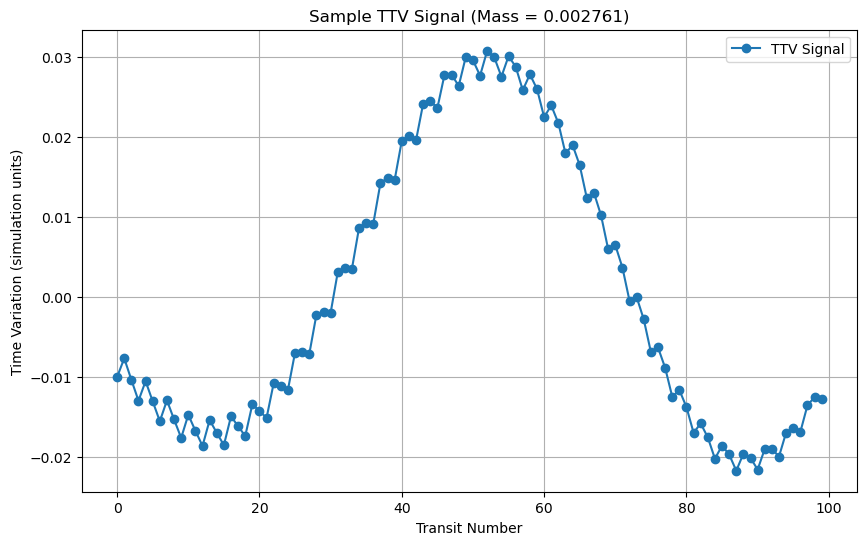

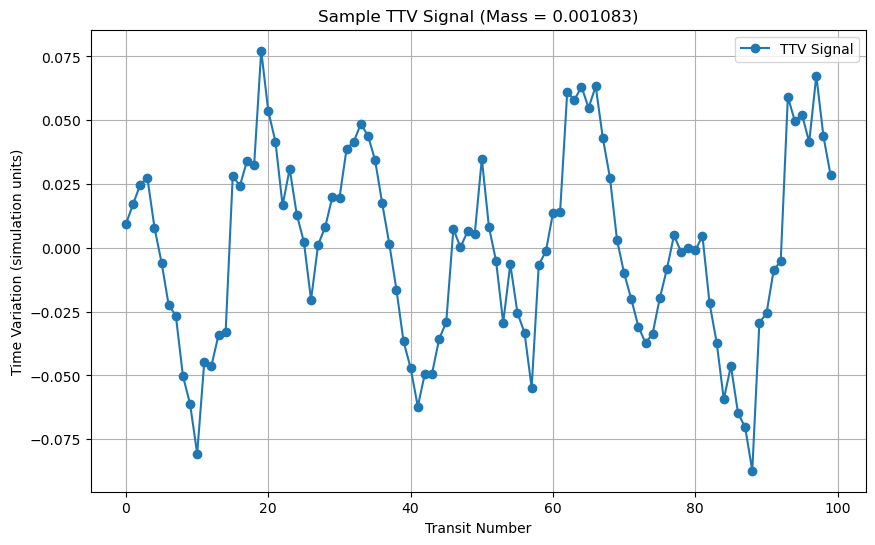

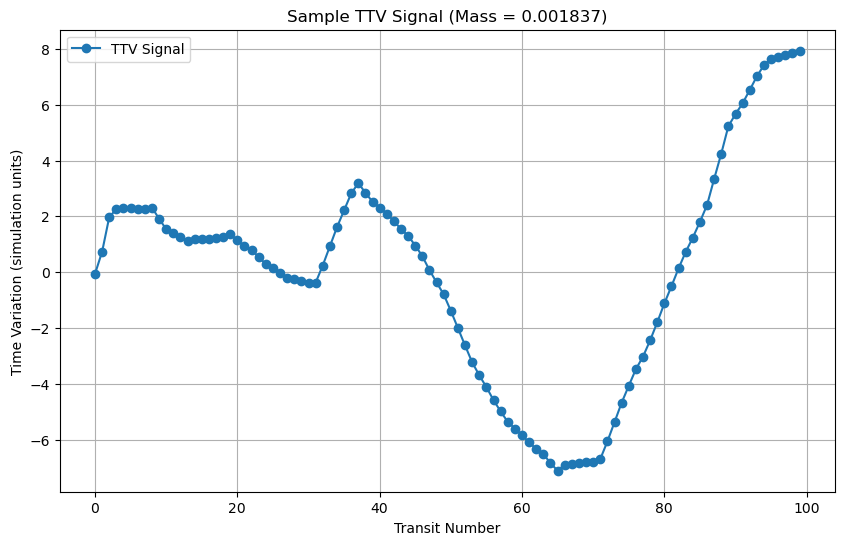

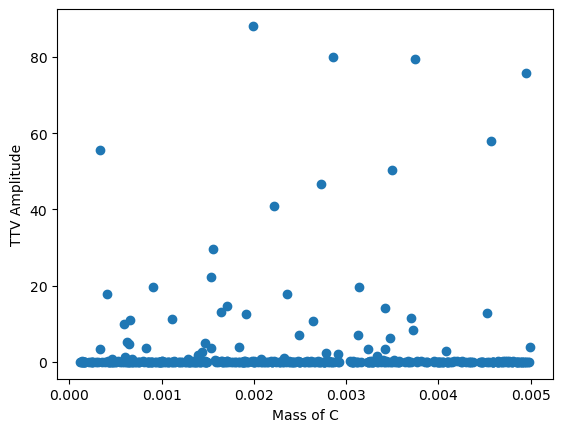


Starting model training...
Epoch [10/200], Train Loss: 0.047123, Val Loss: 0.358133
Epoch [20/200], Train Loss: 0.046091, Val Loss: 0.361830
Epoch [30/200], Train Loss: 0.046127, Val Loss: 0.362434
Epoch [40/200], Train Loss: 0.046045, Val Loss: 0.362438
Early stopping at epoch 41
Training complete.

--- Testing the trained model ---
Test MSE: 0.18541868
Test MAE: 0.33511566

Sample predictions:
  Actual: 1.715752, Predicted: 2.827720
  Actual: 1.742559, Predicted: 2.807719
  Actual: 3.221214, Predicted: 2.894904
  Actual: 2.654564, Predicted: 2.843626
  Actual: 3.082798, Predicted: 2.827837


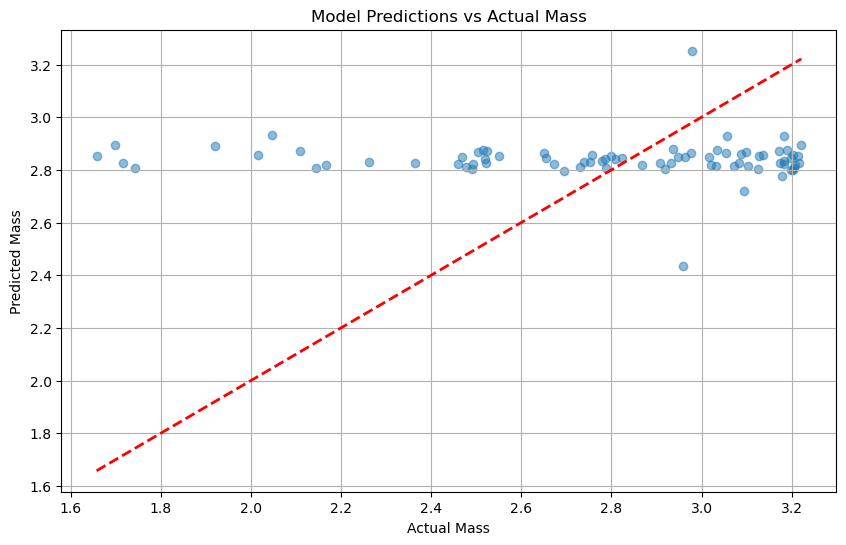

Standard Deviation of predictions: 0.07343712
Label StdDev: 1.1289806318456288
Prediction StdDev: 0.199538454413414
Physical Correlation (TTV Strength vs Mass): 0.0413


In [34]:
from scipy.stats import pearsonr

import numpy as np
import rebound
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#-----------------------------------------------------------------------------
# Utility Functions
#-----------------------------------------------------------------------------

def detect_transits(sim, integration_time, dt, max_transits, planet_index, star_index=0):
    """
    Detects transit times by monitoring when the planet crosses in front of the star.
    A transit occurs when the planet's y-coordinate changes sign (crosses y=0 plane).
    """
    transit_times = []
    
    star = sim.particles[star_index]
    planet = sim.particles[planet_index]
    
    # Get initial position relative to star
    prev_y = planet.y - star.y
    
    time = 0
    while time < integration_time and len(transit_times) < max_transits:
        sim.integrate(sim.t + dt)
        time = sim.t
        
        # Current position relative to star
        curr_y = planet.y - star.y
        
        # Check if planet crossed the y=0 plane (transit condition)
        # Also check x > 0 to ensure it's crossing in front of the star
        if prev_y * curr_y < 0:  # Sign change
            x_rel = planet.x - star.x
            if x_rel > 0:  # Planet is in front of star
                # --- LINEAR INTERPOLATION ---
                # We know the crossing happened between (time - dt) and (time)
                # This finds exactly where Y was 0
                weight = -prev_y / (curr_y - prev_y)
                precise_time = (time - dt) + (weight * dt)
                transit_times.append(precise_time)
        
        prev_y = curr_y
    
    return np.array(transit_times)


def calculate_ttvs(transit_times_perturbed, transit_times_unperturbed):
    """
    Calculates TTVs by subtracting the unperturbed transit times from the perturbed ones.
    """
    min_len = min(len(transit_times_perturbed), len(transit_times_unperturbed))
    if min_len == 0:
        return np.array([])
    ttvs = transit_times_perturbed[:min_len] - transit_times_unperturbed[:min_len]
    return ttvs

def detrend_ttv(ttv_data):
    """Removes the linear trend from a single TTV array."""
    N = len(ttv_data)
    # Create an array of transit numbers (0, 1, 2, ..., N-1)
    transit_numbers = np.arange(N)
    
    # Fit a straight line (polynomial of degree 1)
    # P[0] is the slope, P[1] is the intercept
    P = np.polyfit(transit_numbers, ttv_data, 1)
    
    # Calculate the linear trend line
    trend = P[0] * transit_numbers + P[1]
    
    # Subtract the trend
    return ttv_data - trend
    

#-----------------------------------------------------------------------------
# ### --- PHASE 1: GENERATE TRAINING DATA --- ###
#-----------------------------------------------------------------------------

def generate_simulation_data(num_simulations, max_transits, dt, integration_time=1000):
    """
    Generates training data by running N-body simulations with varying parameters.
    """
    print("Starting data generation...")

    all_features = []
    all_masses = []
    all_periods_c= []
    failed_sims = 0

    # Resonance targets
    resonances = [1.25, 1.333, 1.5, 2.0, 3.0]


    for i in range(num_simulations):  # Loop to create multiple simulations with random parameters
        if (i + 1) % 10 == 0:
            print(f"  Running simulation {i+1}/{num_simulations}...")       # Progress update every 10 simulations
        
        try:
            # 1. Planet B (Visible, transiting planet) - allow modest variation
            m_b = np.random.uniform(1e-4, 1.5e-4)             # mass of planet B
            P_b = np.random.uniform(1.0, 2.0) # Keep this so the AI learns scale P_b = np.random.uniform(1.0, 2.0)                   # period
            e_b = np.random.uniform(0.0, 0.2)                   # eccentricity B
            #omega_b = np.random.uniform(0.0, 2*np.pi)             # arg of periastron B
            #M_b = np.random.uniform(0.0, 2*np.pi)                 # mean anomaly B
            #inc_b = np.deg2rad(np.random.normal(0.0, 1.0))        # small inclination for B (radians)

            
            
            # 2. Planet C (Hidden perturber - Invisible to AI)
            if True: #np.random.rand() < 0.35: # 35% Resonant
                ratio = np.random.choice(resonances) + np.random.uniform(-0.05, 0.05)
            else:
                ratio = np.random.uniform(1.5, 6.6)

            ############
            #ratio = 2.1
            ###########

            m_c = np.random.uniform(1e-4, 5e-3) # 0.5 to 5 Jupiter Masses               
            P_c = P_b * ratio
            e_c = np.random.uniform(0.0, 0.2)                   # eccentricity C
            #inc_c = np.deg2rad(np.random.normal(0, 3.0))

            # 3. GENERATE UNIQUE UNPERTURBED REFERENCE
            # This is what Planet B would do if Planet C didn't exist
            sim_unperturbed = rebound.Simulation()
            sim_unperturbed.dt = dt     # simulation time step
            sim_unperturbed.integrator = "whfast"
            sim_unperturbed.add(m=1.0)                      # star A
            sim_unperturbed.add(m=m_b, P=P_b, e=e_b) #, inc=inc_b, omega=omega_b, M=M_b)
            unperturbed_transits = detect_transits(sim_unperturbed, integration_time, dt, max_transits, 1)

            # 4. GENERATE PERTURBED SYSTEM
            sim_perturbed = rebound.Simulation()
            sim_perturbed.dt = dt     # simulation time step
            sim_perturbed.integrator = "whfast"
            sim_perturbed.add(m=1.0)                      # star A
            sim_perturbed.add(m=m_b, P=P_b, e=e_b) #, inc=inc_b, omega=omega_b, M=M_b)
            sim_perturbed.add(m=m_c, P=P_c, e=e_c) #, inc=inc_c) # The hidden perturber
            sim_perturbed.move_to_com()
            perturbed_transits = detect_transits(sim_perturbed, integration_time, dt, max_transits, 1)


            # 5. CALCULATE TTVs
            if len(unperturbed_transits) >= max_transits and len(perturbed_transits) >= max_transits:

                # Calculate raw transits
                ttv_vec = (perturbed_transits[:max_transits] - unperturbed_transits[:max_transits])
                # detrend the transits
                ttv_vec = detrend_ttv(ttv_vec)
                #######################
                # amplify signal to make it more readable
                #ttv_vec = ttv_vec * 100000
                #ttv_vec = (ttv_vec / P_b) * 1e6  # Parts per million (ppm) of the orbit
                ########################
                ttv_amplitude = np.std(ttv_vec)

                # Build feature array out of only planet B's properties
                phys_features = np.array([
                    m_b, 
                    P_b, 
                    e_b#, 
                    #np.sin(omega_b), 
                    #np.cos(omega_b)
                ], dtype=float)

                sample_features = np.hstack(([ttv_amplitude], ttv_vec, phys_features))
                all_features.append(sample_features)
                all_masses.append(m_c) # Label
                all_periods_c.append(P_c) # Bookkeeping
            else:
                failed_sims += 1
                
        except Exception as e:      # Catch any errors during simulation
            failed_sims += 1
            if failed_sims <= 3:  # Only print first few errors
                print(f"  Simulation {i+1} failed: {e}")

    print(f"Data generation complete. Generated {len(all_features)} samples.")
    if failed_sims > 0:
        print(f"Failed simulations: {failed_sims}/{num_simulations}")
    
    return np.array(all_features), np.array(all_masses), np.array(all_periods_c)  # Return periods too


#-----------------------------------------------------------------------------
# ### --- PHASE 2: DEFINE AND TRAIN THE MACHINE LEARNING MODEL --- ###
#-----------------------------------------------------------------------------

""" class MassPredictor(nn.Module):
    ""
    Enhanced Neural Network to predict planet mass from TTV signal.
    Uses batch normalization and dropout for better generalization.
    ""
    def __init__(self, input_size):      # means we expect 40 TTV measurements as input
        super(MassPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),     # Outputs 128 numbers, output = weights x input + bias
            nn.BatchNorm1d(128),            # Normalizes 128 outputs (helps to make training stable and faster)
            nn.ReLU(),                      # Rectified Linear Unit, makes negative values = 0, keeps positive values, output = max(0, input)
            nn.Dropout(0.2),                # Randomly sets 20% of inputs to zero (helps prevent overfitting)
            nn.Linear(128, 64),             # Same thing again, now 128 to 64 outputs
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),              # Same thing again, now 64 to 32 outputs
            nn.ReLU(),
            nn.Linear(32, 1)                # Final output is a single number (predicted mass)
        )

    def forward(self, x):                   # Defines how data passes through the network, x is input data
        return self.network(x) """

######################################
class MassPredictor(nn.Module):
    def __init__(self, input_size):
        super(MassPredictor, self).__init__()
        # self.network = nn.Sequential(
        #     # Layer 1
        #     nn.Linear(input_size, 512), 
        #     nn.LeakyReLU(0.1),
        #     nn.Dropout(0.3), 

        #     # Layer 2
        #     nn.Linear(512, 256),
        #     nn.LeakyReLU(0.1),
        #     nn.Dropout(0.3), # Reduced dropout slightly to keep more signal
            
        #     # Layer 3
        #     nn.Linear(256, 128),
        #     nn.LeakyReLU(0.1),
        #     nn.Dropout(0.3),
            
        #     # Layer 4
        #     nn.Linear(128, 64),
        #     nn.LeakyReLU(0.1),
            
        #     # Layer 5
        #     nn.Linear(64, 32),
        #     nn.LeakyReLU(0.1),
            
        #     # Output Layer
        #     nn.Linear(32, 1)
        # )
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1), # Add a tiny bit of dropout to help with the "messier" data
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)
#####################################

def train_model(model, X_train, y_train, X_val, y_val, epochs=200, batch_size=8):           
    """
    Function to train the neural network model.
    X_train, y_train: training data (TTVs)and labels (masses)
    X_val, y_val: validation features (to check overfitting) and validation labels 
    epochs : how many times to loop over the training data
    batch_size : size of mini-batches for training
    Enhanced training loop with validation and early stopping.
    """
    print("\nStarting model training...")
    
    # Convert from Numpy to PyTorch tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) # Reshape to be a column vector
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    criterion = nn.HuberLoss()                                                            
    #optimizer = optim.Adam(model.parameters(), lr=1e-5)                                # Adam optimizer, an advanced version of gradient descent, all the weights and biases in the network
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)      # Reduce learning rate if validation loss plateaus # Patience = 5 epochs, will reduce learning rate if no improvement in 5 epochs

    best_val_loss = float('inf')            # Tracks best validation loss seen
    patience_counter = 0                    # Counts epochs without improvement
    max_patience = 30                       # Stop training if no improvement for 30 epochs

    for epoch in range(epochs):             # One epoch = one full loop over the training data
        model.train()                       # Sets model to training mode
        
        # Mini-batch training
        train_loss = 0                      # Accumulates training loss over batches
        indices = torch.randperm(len(X_train_t))    # Shuffle training data indices, PREVENTS FROM LEARNING ANY KIND OF ORDER IN THE DATA
        for i in range(0, len(X_train_t), batch_size): # Processes batch_size samples at a time
            # Extract one batch of data using shuffled indices
            batch_indices = indices[i:i+batch_size]
            batch_X = X_train_t[batch_indices]      
            batch_y = y_train_t[batch_indices]      
            
            outputs = model(batch_X)        # Forward pass: runs data through network to get predictions
            loss = criterion(outputs, batch_y)  # Calculate loss, how wrong are the preditions? compares model outputs to actual labels
            
            optimizer.zero_grad()           # Clear gradients before backward pass
            loss.backward()                # Backpropagation: compute gradients, uses calculus chain rule automatically, dloss/dweight = gradient, for every weight in the network
            optimizer.step()               # Update weights using optimizer, New weights = old weights - learning rate x dloss/dweight
            train_loss += loss.item()       # accumulate loss for this batch, .item() gets the scalar value from the tensor
        
        # Validation
        model.eval()                    # Sets model to evaluation mode
        with torch.no_grad():           # No need to compute gradients during validation
            # Run validation data through the model to get predictions
            val_outputs = model(X_val_t)     
            val_loss = criterion(val_outputs, y_val_t)
        
        scheduler.step(val_loss)        # Adjust learning rate based on validation loss
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(X_train_t):.6f}, Val Loss: {val_loss.item():.6f}')
        
        # Validation loss check for early stopping
        if val_loss < best_val_loss:        # Saves best model and weights if validation loss improved
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()        # state_dict() contains all parameters, weights and biases of the model
        else:                                   # No improvement in validation loss
            patience_counter += 1
            if patience_counter >= max_patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break
    
    print("Training complete.")
    return model


#-----------------------------------------------------------------------------
# ### --- PHASE 3: PUTTING IT ALL TOGETHER --- ###
#-----------------------------------------------------------------------------

if __name__ == "__main__":  # Only runs if this file is executed directly
    
    dt = 0.05 # define time step for simulations 

    # 1. Generate the data
    X_raw, y_raw, p_hidden = generate_simulation_data(num_simulations=500, max_transits=100, dt=dt)
    
    if len(X_raw) < 10:  # Merely a safety check
        print("\nNot enough data generated to train. Increase `num_simulations`.")
    else:
        # 2. Scaling
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        ################################
        #X_ttv_only = X_raw[:, :101] # Replace 40 with your max_transits
        #X_scaled = scaler_X.fit_transform(X_ttv_only)      # Tranforms to have mean 0 and stddev 1

        #############################
        X_scaled = scaler_X.fit_transform(X_raw)      # Tranforms to have mean 0 and stddev 1


        y_earth_masses = y_raw * 332946.0
        y_log = np.log10(y_earth_masses)
        y_scaled = scaler_y.fit_transform(y_log.reshape(-1, 1)).flatten()

        # 3. Train/test split 
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_scaled, test_size=0.2, random_state=42
        )
        
        # Simple split
        X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
        )

        
        # 5. Visualize sample TTV signal
        plt.figure(figsize=(10, 6))
        plt.plot(X_raw[0][1:101], 'o-', label='TTV Signal')
        plt.title(f'Sample TTV Signal (Mass = {y_raw[0]:.6f})')
        plt.xlabel('Transit Number')
        plt.ylabel('Time Variation (simulation units)')
        plt.legend()
        plt.grid(True)
        plt.show()

        # 5. Visualize sample TTV signal
        plt.figure(figsize=(10, 6))
        plt.plot(X_raw[1][1:101], 'o-', label='TTV Signal')
        plt.title(f'Sample TTV Signal (Mass = {y_raw[1]:.6f})')
        plt.xlabel('Transit Number')
        plt.ylabel('Time Variation (simulation units)')
        plt.legend()
        plt.grid(True)
        plt.show()

        # 5. Visualize sample TTV signal
        plt.figure(figsize=(10, 6))
        plt.plot(X_raw[2][1:101], 'o-', label='TTV Signal')
        plt.title(f'Sample TTV Signal (Mass = {y_raw[2]:.6f})')
        plt.xlabel('Transit Number')
        plt.ylabel('Time Variation (simulation units)')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.scatter(y_raw, X_raw[:, 0])
        plt.xlabel("Mass of C")
        plt.ylabel("TTV Amplitude")
        plt.show()

        # 6. Train the model
        input_size = X_train.shape[1]
        model = MassPredictor(input_size=input_size)                             # Creates NN with correct input size
        model = train_model(model, X_train, y_train, X_val, y_val)    # Train the model for 50 epochs

        # 7. Test the model
        print("\n--- Testing the trained model ---")
        model.eval()
        with torch.no_grad():       # Switching to evulation mode where we dont compute gradients
            X_test_t = torch.tensor(X_test, dtype=torch.float32)    # Convert test data to tensor
            predictions = model(X_test_t).numpy().flatten()         # And back to Numpy array

            # Inverse transform / Denormalize to get actual values
            predictions_actual = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()       
            y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
            
            # Calculate error metrics
            mse = np.mean((predictions_actual - y_test_actual)**2)
            mae = np.mean(np.abs(predictions_actual - y_test_actual))
            
            print(f"Test MSE: {mse:.8f}")
            print(f"Test MAE: {mae:.8f}")
            print(f"\nSample predictions:")
            for i in range(min(5, len(y_test_actual))):
                print(f"  Actual: {y_test_actual[i]:.6f}, Predicted: {predictions_actual[i]:.6f}")
        
        # 8. Plot predictions vs actual
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test_actual, predictions_actual, alpha=0.5)
        plt.plot([y_test_actual.min(), y_test_actual.max()], 
                 [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
        plt.xlabel('Actual Mass')
        plt.ylabel('Predicted Mass')
        plt.title('Model Predictions vs Actual Mass')
        plt.grid(True)
        plt.show()

        print("Standard Deviation of predictions:", np.std(predictions_actual))
        print(f"Label StdDev: {y_test.std()}")
        print(f"Prediction StdDev: {predictions.std()}")
        

        # Check if TTV standard deviation correlates with Mass at all
        ttv_stds = np.std(X_raw[:, :40], axis=1)
        correlation, _ = pearsonr(ttv_stds, y_raw)
        print(f"Physical Correlation (TTV Strength vs Mass): {correlation:.4f}")